# Deep Learning: Optimizer, Loss & Fitting

## Plan

1. Reminders
2. What does `model.compile(...)` mean?
3. What is exactly `model.fit(...)`?
4. Regularization layers
5. Side note: Save and load models

# 0. Reminders

#### The neural network $f_\theta$ is just a composition of linear combinations

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/02/neuralnet_0.png" alt="Neural network" style="height:350px;"/>

- A neural network is a stack of layers
- Each layer is composed of neurons
- A neuron is a { **linear combination** } + { **activation function** }

**Keras Library**

We use the [Keras](https://www.tensorflow.org/api_docs/python/tf/keras) library to build neural networks. 

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/02/keras_library.jpg" alt="Keras" style="height:250px;"/>

- Keras lives now within the [Tensorflow package](https://www.tensorflow.org/) (developed by Google, which also developed the [Tensorflow Playground](https://playground.tensorflow.org/#activation=tanh&batchSize=10&dataset=circle&regDataset=reg-plane&learningRate=0.03&regularizationRate=0&noise=0&networkShape=4,2&seed=0.72866&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false) ).
- You have to import `tensorflow.keras` instead of `keras`

- Check the [Tensorflow Keras](https://www.tensorflow.org/guide/keras?hl=fr) documentation, _not_ the [Keras](https://keras.io/) documentation.

- Keras has fast evolving code & documentation



**A neural network is fully specified in three steps**

In [ ]:
###### Keras cheatsheet ######

# STEP 1: ARCHITECTURE
model = Sequential()
model.add(layers.Dense(100, input_dim=128, activation='relu'))  # /!\ Must specify input size
model.add(layers.Dense(10, activation='relu'))
model.add(layers.Dense(10, activation='relu'))
model.add(layers.Dense(5, activation='softmax')) # /!\ Must correspond to the task at hand

# STEP 2: OPTIMIZATION METHODS
model.compile(loss='categorical_crossentropy', optimizer='adam')

# SETP 3: DATA AND FITTING METHODS
model.fit(X, y, batch_size=32, epochs=100)

**The last layer must correspond to the task at hand**

In [ ]:
### REGRESSION WITH 1 OUTPUT
model.add(layers.Dense(1, activation='linear'))


### REGRESSION WITH 16 OUTPUTS
model.add(layers.Dense(16, activation='linear'))


### CLASSIFICATION WITH 2 CLASSES
model.add(layers.Dense(1, activation='sigmoid'))


### CLASSIFICATION WITH 14 CLASSES
model.add(layers.Dense(14, activation='softmax')

# 1. Compiling

```python
model.compile(loss=..., 
              optimizer=..., 
              metrics=...)
```
This corresponds to the way the Neural Network optimizes its parameters $\theta$. 

In [ ]:
# REGRESSION
model.compile(loss='mse',
              optimizer='adam',
              metrics=['mae'])

# CLASSIFICATION WITH 2 CLASSES
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

# CLASSIFICATION WITH N (let's say 14) CLASSES
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy', 'precision'])

### Big picture

We have: 
- The **model** $f_{\theta}$ that predicts $\hat{y} = f_{\theta}(X)$
- The **loss function** $L_x(\theta)$ which measures a "smooth" distance between $\hat{y}$ and $y$ $\rightarrow$ used to optimize $\theta$.
- The **metric(s)** that measures "human" distances between $\hat{y}$ and $y$ $\rightarrow$ used for performance evaluation.

## 1.1 The `metrics` 

= human measures of _how good_ the predictions are

$ \rightarrow $ computed by **forward propagation** at each epoch

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/02/forwardprop.jpg" alt="Neural network" style="height:250px;"/>

🤔 What do we mean by **forward propagation** ? 

👇 Let's illustrate it through a quite simple Neural Network:

<img src="https://github.com/lewagon/data-images/blob/master/DL/forward_pass_graph.png?raw=true" width=600 height = 300>

❓ How many parameters does this neural network have ❓

$ \large \left( (\color{green}{5} + 1) \times \color{blue}{4} \right) + \left(  (\color{blue}{4} + 1) \times 	\color{magenta}{1} \right) = 24 + 5 = 29$

**💡 [Forward Propagation](https://github.com/lewagon/data-images/blob/master/DL/forward_pass_graph.png?raw=true) = 1 matrix multiplication per layer**

<img src="https://github.com/lewagon/data-images/blob/master/DL/forward_pass_matrix.png?raw=true" width=500 height = 250>



**Common metrics**
- for ***classification tasks***:
    - Precision, Recall, Accuracy, F1-score, ROC-AUC, ... 
- for ***regression tasks***:
    - MSE, MAE, RMSE, RMSLE, R-squared, ...

🧐 _Did you know?_

All metrics (and losses) are based on the mathematical notions of:
- **distances** (the smaller the better) : e.g. Euclidian, Manhattan, ...
- or **similarities** (the larger the better): e.g. Cosine, Jaccard ...

between two points $A,B$ in a vector space

📚 [Read more](https://aiaspirant.com/distance-similarity-measures-in-machine-learning/)

In Keras ([📚 Docs about the metrics](https://www.tensorflow.org/api_docs/python/tf/keras/metrics)):

```python
# use strings for quick access
model.compile(metrics=['accuracy', 'precision'])

# use Keras metric objects for fine-tuning
metric = keras.metrics.AUC(
    num_thresholds = 200,
    curve='ROC', # or curve='PR'
)
model.compile(metric=metric)

# Custom metrics
def custom_mse(y_true, y_pred):
    squared_diff = tf.square(y_true - y_pred)
    return tf.reduce_mean(squared_diff)

model.compile(metrics=[custom_mse])
```



💻 Do not hesitate to play with `Tensor` objects, they are quite similar to Numpy `Array`

In [ ]:
import tensorflow as tf

X = tf.ones((3,3))
X

<tf.Tensor: shape=(3, 3), dtype=float32, numpy=
array([[1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.]], dtype=float32)>

In [ ]:
X.numpy()

array([[1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.]], dtype=float32)

## 1.2 The `loss function` $L_x(\theta)$

= the function you choose to optimize your algorithm!

- `.fit()` aims at finding $\theta$ that **minimizes** the loss function

- Not necessarily equal to the metric
- Only one loss per model (whereas you can your model with different metrics!)
- Must be "smooth" (so that we can compute its gradient)


### Loss function has to be "smooth"

It is not possible to use any function for the loss:

- Loss functions must be **continuous** and **(sub)differentiable** with respect to $\theta$
- i.e. the distance between $f_{\theta}(X)$ and $y$ has to vary smoothly when $\theta$ varies
- So you can compute it's gradient

Your "energy landscape" has to be smooth (but maybe very complex) : 
<div style="display:flex;justify-content:center;">
    <img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/02/energy.png" alt="Energy Landscape" style="width:400px;"/>
</div>




**Examples:**   
❌ __Accuracy__ _jumps_ from 0 to 1 as $\theta$ varies  
✅ __Cross-entropies__ output probabilities which vary smoothly

##### Binary Cross-Entropy (= Log Loss) 

$$
\large Log\ Loss = - \frac{1}{n}\sum_{i=0}^n  y_i log( \hat{y}_i ) + ( 1 - y_i ) log(1- \hat{y}_i )
$$

- $y=1 \Rightarrow Log\ Loss = - log(\hat{y})$
- $y=0 \Rightarrow Log\ Loss = - log(1 - \hat{y})$

<img src="https://github.com/lewagon/data-images/blob/master/ML/logloss.png?raw=true">

💡 The "Cross-Entropy" name comes from [📺 Shannon's Information Theory](https://www.youtube.com/watch?v=ErfnhcEV1O8)

In Keras?

```python
# use strings for quick access
model.compile(loss = "binary_crossentropy")


# use Keras metric objects for fine-tuning
loss = keras.losses.BinaryCrossentropy(...)
model.compile(loss = loss)

# Custom losses
def custom_mse(y_true, y_pred):
    squared_diff = tf.square(y_true - y_pred)
    return tf.reduce_mean(squared_diff)

model.compile(loss=custom_mse)
```
Pick a loss available in the [documentation](https://www.tensorflow.org/api_docs/python/tf/keras/losses)

### Summary

We have: 
- The **model** $f_{\theta}$ that predicts $\hat{y} = f_{\theta}(X)$
- The **loss function** $L_x(\theta)$ which measures a "smooth" distance between $\hat{y}$ and $y$ $\rightarrow$ used to optimize $\theta$.
- The **metric(s)** that measures "human" distances between $\hat{y}$ and $y$ $\rightarrow$ used for performance evaluation.

➡️ Next step: **how do we minimize the loss?**

👉 This is where the **optimizer** comes in!

# 2. The `optimizer`

<center><img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/02/backpropagation.gif' width=600></center>

## 2.1 Forward vs. Backward Propagation

The optimizer is "fed" with data **batch-by-batch** to update the weights of the model iteratively.

At each iteration $\color{red}{k}$:
1. **Forward propagation**
    - Given _some_ input $X_{batch}$, the model computes $f_{\theta_{\color{red}{k}}}(X_{batch})$ 
    - The loss for this batch is computed $L(\theta_{\color{red}{k}})$
    
2. **Backward propagation**
    - The gradient of this loss $\nabla L$ is computed
    - The weights are updated using this gradient: $\theta^{\color {red}{(k+1)}} \leftarrow Update(\theta^{\color {red}{(k)}}, \nabla L)$

Why is it called `backpropagation`?

- Remember that we need to compute the gradient of the loss
- It consists of a very large number `p` of partial derivatives (one per weight) $${\displaystyle \nabla L(\theta)={\begin{bmatrix}{\frac {\partial L}{\partial \color{blue}{\theta_{1}}}}(\theta) \\ ... \\ {\frac {\partial L}{\partial \color{blue}{\theta_{p}}}}(\theta)\end{bmatrix}}.}$$

If we were to compute them **numerically** one-by-one using the definition:
$$\frac{{\partial L}}{{\partial \color{blue}{\theta_{i}}}} = \lim _{h\to 0}{\frac {L(\color{blue}{\theta_{i}} +h)-L(\color{blue}{\theta_{i}})}{h}}.$$ 

we would need to compute `p` forward passes per iteration! 🤯

💡 Instead, mathematicians have developed a clever **analytical** method to compute all these partial derivatives together:

- The network is made up of many simple **composite** functions (ex: addition, multiplication, sigmoids, ReLU ...)
- Individually, their derivatives are easy to compute (ex: derivative of ReLU is either 0 or 1)
- The derivative of the loss can be obtained from these individual contributions using the **Chain Rule**

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/02/chain_rule.png'>

☝️ If we iterate backward from the output layer, we can <b><font  color='magenta'>re-use</font></b> many terms computed at previous steps.

📺 [Khan Academy - Chain Rule (5 min)](https://www.youtube.com/watch?v=0T0QrHO56qg)

**Key benefits? The speed ⚡️**

One iteration (update) on a minibatch uses only:

➡️ 1 forward pass 
- computes the outputs for each observation of the minibatch
- computes the loss for this minibatch
- and _stores intermediary computations in RAM_

⬅️ 1 backward pass through the network (_re-use intermediary values for the chain rule_)

&nbsp;  
💡  <font color='blue'>The chain rule allows backpropagation to take (roughly) the same time as a forward pass!</font>

Popularized [in 1987](http://yann.lecun.com/ex/research/index.html), this discovery is at  the origin of a rush of people using neural networks.

❗️ **Vanishing gradient** phenomenon ❗️

> The weights of the first (deeper) layers are **harder** to move than from the last layer (outputs)

<img src="https://miro.medium.com/max/480/1*Ku54qmCryZVBaIc6g8rjGA.gif">

👉 [Playground example](https://playground.tensorflow.org/#activation=tanh&batchSize=16&dataset=circle&regDataset=reg-plane&learningRate=0.01&regularizationRate=0&noise=0&networkShape=4,4,4,4,4&seed=0.13677&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false&regularization_hide=false&showTestData_hide=true&stepButton_hide=false&activation_hide=false&problem_hide=false&batchSize_hide=false&dataset_hide=false&resetButton_hide=false&discretize_hide=true&playButton_hide=false&learningRate_hide=false&regularizationRate_hide=false&percTrainData_hide=false&numHiddenLayers_hide=false)

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/02/tensorflow_playground.png' width=600>



## 2.2 Which optimizer to choose?

Simple gradient descent is not good enough in Deep Learning.  
Loss functions are too complex and the optimizer gets stuck at **local minima**.

The [documentation](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers) offers multiple choices: Adam, SGD, RMSProp, Adadelta, ...

<img src=https://miro.medium.com/max/800/1*zVi4ayX9u0MQQwa90CnxVg.gif width=500>

- <font color=cyan>Gradient</font>  
- <font color=magenta>Momentum</font> (adds inertia)

<img src='https://miro.medium.com/max/1400/1*47skUygd3tWf3yB9A10QHg.gif' width=500>

- <font color=cyan>Gradient</font>
- <font color=magenta>Momentum</font> (adds inertia)
- <font color=grey>AdaGrad</font> (adaptative learning rate per feature - priorize weakly updated params)
- <font color=green>RMSProp</font> (adds decay - only recent gradient matters)
- <font color=blue>Adam</font> (all combined)

📚[Credits](https://towardsdatascience.com/a-visual-explanation-of-gradient-descent-methods-momentum-adagrad-rmsprop-adam-f898b102325c)

### Adam = best choice of optimizer to start with

***OUTDATED AND NOT PROVEN***

❗️ For RNN (Recurrent Neural Network), historically, people have used `RMSProp` optimizer.

# 3. `optimizer` hyper-parameters

When you initialize an optimizer using a string, you start with the default hyperparameters.
```python
model.compile(loss=..., optimizer='adam')
```


You can select your own hyperparameters thanks to the following syntax: 

```python
opt = tensorflow.keras.optimizers.Adam(
    learning_rate=0.01, beta_1=0.9, beta_2=0.99
)
model.compile(loss=..., optimizer=opt)
```

## 3.1 `learning_rate`

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/02/learning_rate.png" alt="Learning rate" style="height:250px;"/>


- Start with the default implementation.
- Think about this rate as the **amount of change on the weights you want at each update**.
- Smaller rates will require more epochs

💡 For a deeper understanding of the learning rate, let's check this [animation](https://distill.pub/2017/momentum/).
<br>

**🏋🏽‍♂️** : [Schedulers](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/schedules) (cf challenges) offer some clever ways to have a changing learning rate during training.

##  3.2 `batch_size`

Let's say that you have 100 samples $X_1, X_2, X_{100}$ and `batch_size=10`

**One epoch** corresponds to:
- $\theta^{(0)} \rightarrow \theta^{(1)}$ on the samples ($X_{1}$, $X_{2}$, $\dots$, $X_{10}$),
- $\theta^{(1)} \rightarrow \theta^{(2)}$ on the samples ($X_{11}$, $X_{12}$, $\dots$, $X_{20}$),
- ...
- $\theta^{(9)} \rightarrow \theta^{(10)}$ on the samples ($X_{91}$, $X_{92}$, $\dots$, $X_{100}$),

👉 Refer to the unit *`05-Machine-Learning/04-Under-The-Hood`* on [Kitt](https://kitt.lewagon.com/)

- The smaller the batch, the more stochastic the process is and the faster it may converge
- The larger the batch, the better it generalizes, but the more computationally intensive it becomes

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/SGD.png" width="600"/>
<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/loss_bgd_sgd.png" width="600"/>

### Which batch size to choose?

Yann Le Cun has an answer for you: 

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/02/batch_size_twitter.png" alt="Batch Size" style="height:250px;"/>

In reality, it depends on the size of your inputs
- 16 or 32 is most for real-word data (eg: $128 \times 128 \times $ images)
- You can use more for very small data (eg: Tabular datasets, tiny images, etc...)

❗ **Remark** ❗ Why a power of 2? $ \rightarrow $ for computational reasons!

## 3.3 `epochs` number?

❗ The larger the batch size, the more epochs you will need ❗

&nbsp;  
**How many epochs?**

It does not matter, as many as possible as long as the neural network is able to generalize to unseen data. 

🤔 **When does my model start overfitting?**

💡 _Hint_: Do _NOT_ use your real test set.

#### Train/Val/Test split

❗️ If you use the test set to stop your algorithm (to prevent overfitting), you use the test set to _optimize_ your algorithm. ❗️

To prevent this type of data leakage, instead of estimating the loss on the test set, we do it on part of the training set. We call this the **validation set**.

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/02/validation_set.png" alt="Validation set" style="height:350px;"/>

❗️**K-fold cross-val** is better than a single holdout❗️

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/machine-learning/train_test_crossval.png' width=300>

&nbsp;  

❗️ **Cross-val in deep learning can be very time consuming**  ❗️

From now on, we will only do the split once.  
In real life, don't forget to perform a real cross-validation. 

In Keras, we have two options:
```python
# Give validation set explicitly
history = model.fit(X_train, y_train,
          validation_data=(X_val, y_val), 
          batch_size=16,
          epochs=100)
```

<br>

Or, use directly the `validation_split` keyword:
```python
history = model.fit(X_train, y_train,
          validation_split=0.3, # /!\ LAST 30% of train indexes are used as validation
          batch_size=16,
          epochs=100,)
          # shuffle=True) # Training data is shuffled at each epoch by default 👌
```

Your `history` may then look like this:

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/02/train-val-loss.png' width=400 style='margin:auto'>

## 3.4 `Early stopping`

The previous code evaluates the model on the validation data at the end of each epoch. However, it will not stop training the model even after it starts overfitting.

👉 To properly stop the algorithm from training, we use the **Early Stopping Criterion**.  
- It stops the algorithm if the validation loss at `epoch` $k+1$ is worse than at `epoch` $k$.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

es = EarlyStopping()

model.fit(X_train, y_train,
          batch_size=16,
          epochs=1000,
          validation_split=0.3,
          callbacks=[es])

# "callback" means that the early stopping criterion
# will be called at the end of each epoch

In reality, Neural Networks are **stochastic** algorithms and the loss can look like that: 

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/02/validation_loss.png" alt="Validation loss" style="height:350px;"/>

👉 If you stop the run as soon as the validation loss gets worse, you will stop it too soon, even before 10 epochs.  

We need to allow a given number of iterations without improvement, with the `patience` keyword.

In [ ]:
es = EarlyStopping(patience=20)

model.fit(X_train, y_train,
          batch_size=16,
          epochs=1000,
          validation_split=0.3,
          callbacks=[es])

👇 same patience but restores the weights that correspond to the best validation loss:

In [ ]:
es = EarlyStopping(patience=20, restore_best_weights=True)

model.fit(X_train, y_train,
          batch_size=16,
          epochs=1000,
          validation_split=0.3,
          callbacks=[es])

# 4. Regularization

All the previous steps are somewhat _mandatory_: they are fundamental to building a Neural Network. 

However, in practice, you might still feel lost as to **how** to design the neural network architecture. 

This is absolutely normal when you begin. 


<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/02/meme-no-idea.jpg' width=300 align='center'>

The art of _Deep Learning_ is not to build the best architecture at first sight...

... but to try an initial architecture...  
... and **know what to change to improve it according to the results**! 

This is why practice is so important.

For instance, a common problem is that a Neural Network is **overfitting**! How do we solve it?

&nbsp;

✅ **Early Stopping** criterion _stops_ the model from learning before it overfits.

✅ **Regularization** layers really try to _prevent_ your Neural Net from overfitting (📚 [documentation](https://www.tensorflow.org/tutorials/keras/overfit_and_underfit#strategies_to_prevent_overfitting)).

## 4.1 Regularizers (L1, L2)

The regularization layers act the same way as L1 and L2 regularization in "vanilla" Machine Learning. 

The Neural Network will optimize the loss you declared _plus_ this regularization!


$$L2\ Loss = Loss\ + \color{red}{\alpha} \sum_{i} \theta_i^2$$

$$L1\ Loss = Loss\  + \color{red}{\alpha} \sum_{i} | \theta_i|$$

But... to which $\theta$ do you apply this? All of them? 

👉 <font color='red'>***Layer per layer***</font> 👈

You can actually apply it to:
- All the **weights** $w_i$ of a given layer (also called the `kernel_regularizer`)
- All the **biases** $b_i$ of a given layer (`bias_regularizer`)
- The entire **output** of a given layer (`activity_regularizer`)

❗️ This regularization is "active" only during the training

In [ ]:
from tensorflow.keras import regularizers, Sequential, layers

reg_l1 = regularizers.L1(0.01)
reg_l2 = regularizers.L2(0.01)
reg_l1_l2 = regularizers.l1_l2(l1=0.005, l2=0.0005)

model = Sequential()

model.add(layers.Dense(100, activation='relu', input_dim=13))
model.add(layers.Dense(50, activation='relu', kernel_regularizer=reg_l1))
model.add(layers.Dense(20, activation='relu', bias_regularizer=reg_l2))
model.add(layers.Dense(10, activation='relu', activity_regularizer=reg_l1_l2))
model.add(layers.Dense(1, activation='sigmoid'))

&nbsp;  
❓ What is the number of additional parameters induced by the regularization ❓

In [ ]:
# Answer: zero additional parameters
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 100)               1400      
                                                                 
 dense_1 (Dense)             (None, 50)                5050      
                                                                 
 dense_2 (Dense)             (None, 20)                1020      
                                                                 
 dense_3 (Dense)             (None, 10)                210       
                                                                 
 dense_4 (Dense)             (None, 1)                 11        
                                                                 
Total params: 7,691
Trainable params: 7,691
Non-trainable params: 0
_________________________________________________________________


In [ ]:
# Indeed: for instance layer 2 is regularized
# yet has usual number of parameters
(100 + 1) * 50

5050

## 4.2 Dropout layer 

During the training, at each iteration, the dropout randomly "kills" (=0) the activity from some neurons so their weights are not updated:

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/02/dropout.png" alt="Dropout" style="height:300px;"/>

Consequences: 
- Prevents any neuron from updating its weights only according to a particular input
- Prevents neurons from over-specializing / being too specific to this input and unable to generalize

In [ ]:
model = Sequential()

model.add(layers.Dense(20, activation='relu', input_dim=56))
model.add(layers.Dropout(rate=0.2))  # The rate is the percentage of neurons that are "killed"

model.add(layers.Dense(10, activation='relu'))
model.add(layers.Dropout(rate=0.2))

model.add(layers.Dense(3, activation='softmax'))


# —— What is the number of parameters of the Dropout layer?

In [ ]:
# Zero additional parameters
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_5 (Dense)             (None, 20)                1140      
                                                                 
 dropout (Dropout)           (None, 20)                0         
                                                                 
 dense_6 (Dense)             (None, 10)                210       
                                                                 
 dropout_1 (Dropout)         (None, 10)                0         
                                                                 
 dense_7 (Dense)             (None, 3)                 33        
                                                                 
Total params: 1,383
Trainable params: 1,383
Non-trainable params: 0
_________________________________________________________________


## Pro Tips 💡

<font color=green>**[Strongly recommended]**</font>
- Start your model from the **last layer**
- Implement the **easiest architecture** first
- Stick with the same **batch size** (eg. 32 for large data, more if it fits on RAM). Change it only once your are confident about its impact.
- Don't think about the number of **epochs**: it has to hit your `early_stopping` criterion

<font color=orange>***[Apply wisely]***</font>
- Try to make your model **overfit** before regularizing (it is good to see that your model does learn, even too much!)
- If you can't overfit, try fine-tuning your **learning rate** (or change the model's architecture)
- If train loss was on a *steep decreasing trajectory* when hitting early stopping, chances are that **regularization** will improve performance
- Only then, you can regularize
- Try to regularize the last layers before the first ones

## 5. Bonus (new!) Preprocessing Pipelines in Tensorflow

```python 
from tensorflow.keras.layers.experimental import preprocessing
```

In [ ]:
from sklearn.datasets import make_blobs, make_regression
import pandas as pd
from tensorflow.keras import regularizers, Sequential, layers
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

In [ ]:
def plot_history(history, title=None):
    fig, ax = plt.subplots(1,1)
    ax.plot(history.history['loss'])
    ax.plot(history.history['val_loss'])
    ax.set_title('Model loss')
    ax.set_ylabel('Loss')
    ax.set_xlabel('Epoch')
    ax.legend(['Train', 'Test'], loc='best')
    ax.set_ylim(ymin=0)
    if title:
        fig.suptitle(title)

In [ ]:
# Imagine a dataset with one feature scaled differently

X,y = make_regression(n_samples=500, n_features=5, n_targets=3)
X[:,4]= 100 * X[:,4] + 50
pd.DataFrame(X).head()

,0,1,2,3,4
0,-0.060995,-0.008898,-0.606240,-1.064232,-11.377092
1,0.906992,0.282420,0.261933,-0.892490,73.431349
2,-1.449867,-0.789354,-0.820485,1.003394,228.846071
3,-1.777572,-0.616447,-0.421114,0.536362,-85.798070
4,-0.665721,-1.967192,0.598795,-0.261152,-59.285840


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3)

**Bad option: No scaling**

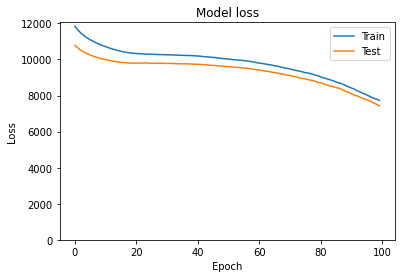

In [ ]:
model = Sequential()
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(8, activation='relu'))
model.add(layers.Dense(3, activation='linear'))

model.compile(loss='mse', optimizer='adam', metrics='mae')

history = model.fit(
    X_train, y_train, validation_data=(X_test, y_test),
    epochs=100, batch_size=32, verbose=0)

plot_history(history)

**Option 1: Scale outside of of the neural network architecture**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

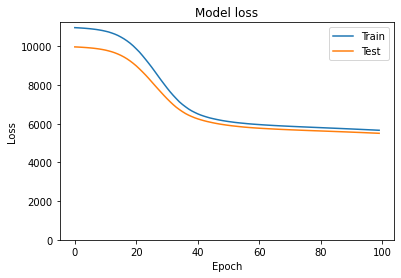

In [ ]:
model = Sequential()
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(8, activation='relu'))
model.add(layers.Dense(3, activation='linear'))

model.compile(loss='mse', optimizer='adam', metrics='mae')

history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=100, batch_size=32, verbose=0)

plot_history(history)

💡 **Option 2**: Integrate scaling **within the model's architecture** using [`Normalization`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/experimental/preprocessing/Normalization) layers

In [ ]:
# from tensorflow.keras.layers.experimental.preprocessing import Normalization

In [ ]:
from tensorflow.keras.layers import Normalization

In [ ]:
normalizer = Normalization() # Instantiate a "normalizer" layer
normalizer.adapt(X_train) # "Fit" it on the train set

In [ ]:
# Once fitted, you can use it as a function

print(normalizer(X_train).numpy().std())
print(normalizer(X_test).numpy().std())

1.0
0.9552177


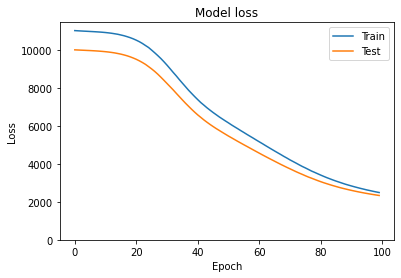

In [ ]:
model = Sequential()

# Use the adapted normalizer as first sequential step
model.add(normalizer)
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(8, activation='relu'))
model.add(layers.Dense(3, activation='linear'))

model.compile(loss='mse', optimizer='adam', metrics='mae')

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100, batch_size=32, verbose=0)

plot_history(history)

👍 Use preprocessing layers whenever they exist. It greatly helps with data-engineering:

- Normalization
- CategoryEncoding (OneHotEncoder)
- TextVectorization (NLP...)
- Resizing (Images...)

Full list of preprocessing layers [📚 here](https://www.tensorflow.org/guide/keras/preprocessing_layers)  


📚 [Pipeline example from A to Z](https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/structured_data/preprocessing_layers.ipynb)

### 4.2 [`CategoryEncoding`](https://www.tensorflow.org/guide/keras/preprocessing_layers#encoding_string_categorical_features_via_one-hot_encoding)

In [ ]:
# from tensorflow.keras.layers.experimental.preprocessing import CategoryEncoding

In [ ]:
# from tensorflow.keras.layers import CategoryEncoding

# X_train = np.array([1, 1, 1, 2, 2, 3])

# encoder = CategoryEncoding(output_mode="binary") # OHE
# encoder.adapt(X_train) # "fit"
# encoder(X_train) # "transform"

In [ ]:
# X_test = np.array([1, 2, 3, 4])
# encoder(X_test)

# One last thing: Save and load models

❗️***Warning***❗️ This section will be extremely important for the Data Science Projects.

* There are numerous reasons you might want to save your model, send it to someone that can load and use it. 

* There are [many options](https://www.tensorflow.org/api_docs/python/tf/keras/models) to do that. Let's see one of them.


```python
from tensorflow.keras import models

# Let's say that you have a `model`
# You can save it:
models.save_model(model, 'my_model')

# and you can load it somewhere else:
loaded_model = models.load_model('my_model')
```

## Bibliography

📚 [In what sense is backprop a fast algorithm](http://neuralnetworksanddeeplearning.com/chap2.html#in_what_sense_is_backpropagation_a_fast_algorithm)  
📺 [3Blue1Brown - Neural Networks - 1h](https://www.youtube.com/watch?v=Ilg3gGewQ5U)  
📺 [Stanford - Graphs, and backpropagation - 1h20](https://youtu.be/d14TUNcbn1k?t=157) 

# Your turn 🚀